# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [29]:
tt_set = pd.read_pickle("pickle_files/training_data_md.pkl")

In [30]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019_HeNan_2015,s1019,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [31]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to MD
dtypes: float64(5), int64(251236), object(1)
memory usage: 4.6+ GB


In [32]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,0,0,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,0,0,0,0,0,0,0,0,0,0,...,61.0,4.60000,0,0,1,0,0,0,1,113.0


In [9]:
snps = Final_data.iloc[:, 0:251229]
snps.head()

NameError: name 'Final_data' is not defined

In [18]:
prt = Final_data.iloc[:, 251237:]
prt.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [33]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,
s100,9.5000,6.26667,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,10.2133,4.00000,116.0,3.40000,0,0,1,0,0,0,1,115.0
s1014,11.8200,7.78667,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,13.2800,6.94667,79.0,3.40000,0,0,1,0,0,0,1,104.0
s1019,10.8400,7.34667,61.0,4.60000,0,0,1,0,0,0,1,113.0


# Define all functions

In [6]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [7]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [8]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [9]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [10]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [11]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [12]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [15]:
#Load file
genotype = pd.read_csv('../gwas_md/top_5percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 12562 entries, 0 to 12561
dtypes: int64(12562)
memory usage: 122.2 MB


In [16]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,0,1,2,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,0,2,1,0,0,0,1,1,...,0,0,0,2,1,0,0,0,0,0
2,2,1,1,2,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,3,1,1,1,0,1,1,0,0,0,...,0,0,2,0,2,0,0,0,1,0
4,4,1,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0


In [17]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,,,,,,,,,,,,,,,,,,,,,
0,1,2,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,2,1,0,0,0,1,1,1,...,0,0,0,2,1,0,0,0,0,0
2,1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1,1,1,0,1,1,0,0,0,0,...,0,0,2,0,2,0,0,0,1,0
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0


In [18]:
column_names = pd.read_csv('../gwas_md/id_names_top5.txt', sep=' ', header=None)

In [19]:
column_names.head

<bound method NDFrame.head of                     0
0         Chr1_123323
1         Chr1_123617
2         Chr1_155648
3         Chr1_213637
4         Chr1_213719
...               ...
12556  Chr20_51666590
12557  Chr20_51666785
12558  Chr20_52212855
12559  Chr20_52247340
12560  Chr20_52266575

[12561 rows x 1 columns]>

In [20]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Columns: 12561 entries, ('Chr1_123323',) to ('Chr20_52266575',)
dtypes: int64(12561)
memory usage: 122.2 MB


In [21]:
genotype.head()

,"(Chr1_123323,)","(Chr1_123617,)","(Chr1_155648,)","(Chr1_213637,)","(Chr1_213719,)","(Chr1_213796,)","(Chr1_214156,)","(Chr1_236602,)","(Chr1_236699,)","(Chr1_324064,)",...,"(Chr20_50433300,)","(Chr20_50674780,)","(Chr20_50927742,)","(Chr20_51166518,)","(Chr20_51479710,)","(Chr20_51666590,)","(Chr20_51666785,)","(Chr20_52212855,)","(Chr20_52247340,)","(Chr20_52266575,)"
0,,,,,,,,,,,,,,,,,,,,,
0,1,2,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,2,1,0,0,0,1,1,1,...,0,0,0,2,1,0,0,0,0,0
2,1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1,1,1,0,1,1,0,0,0,0,...,0,0,2,0,2,0,0,0,1,0
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0


In [22]:
#Adding row names
rows= pd.read_csv('../gwas_md/top_5percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [23]:
genotype.index = rows
genotype.head()

,"(Chr1_123323,)","(Chr1_123617,)","(Chr1_155648,)","(Chr1_213637,)","(Chr1_213719,)","(Chr1_213796,)","(Chr1_214156,)","(Chr1_236602,)","(Chr1_236699,)","(Chr1_324064,)",...,"(Chr20_50433300,)","(Chr20_50674780,)","(Chr20_50927742,)","(Chr20_51166518,)","(Chr20_51479710,)","(Chr20_51666590,)","(Chr20_51666785,)","(Chr20_52212855,)","(Chr20_52247340,)","(Chr20_52266575,)"
"(s63,)",1,2,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
"(s64,)",1,0,2,1,0,0,0,1,1,1,...,0,0,0,2,1,0,0,0,0,0
"(s66,)",1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
"(s70,)",1,1,1,0,1,1,0,0,0,0,...,0,0,2,0,2,0,0,0,1,0
"(s71,)",1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0


In [24]:
genotype.to_csv('genotype_top5_percent_md.txt', sep ='\t', index = True)

In [25]:
!sed 's/[,()\x27]//g'  genotype_top5_percent_md.txt > genotype_top5_percent_md_new.txt

In [26]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top5_percent_md_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
0,s63,1,2,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,s64,1,0,2,1,0,0,0,1,1,...,0,0,0,2,1,0,0,0,0,0
2,s66,1,1,2,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,s70,1,1,1,0,1,1,0,0,0,...,0,0,2,0,2,0,0,0,1,0
4,s71,1,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0


In [27]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Columns: 12562 entries, Unnamed: 0 to Chr20_52266575
dtypes: int64(12561), object(1)
memory usage: 122.2+ MB


In [28]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s63,1,2,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
s64,1,0,2,1,0,0,0,1,1,1,...,0,0,0,2,1,0,0,0,0,0
s66,1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s70,1,1,1,0,1,1,0,0,0,0,...,0,0,2,0,2,0,0,0,1,0
s71,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2894,1,0,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
s2895,1,1,0,0,0,0,0,0,0,0,...,0,2,2,2,1,0,1,2,0,0
s2896,1,0,2,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [41]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LL                 2450 non-null   float64
 1   LW                 2450 non-null   float64
 2   PLH                2450 non-null   float64
 3   VBN                2450 non-null   float64
 4   BeiJing_2013       2450 non-null   int64  
 5   HeNan_2014         2450 non-null   int64  
 6   HeNan_2015         2450 non-null   int64  
 7   HeiLongJiang_2014  2450 non-null   int64  
 8   HeiLongJiang_2015  2450 non-null   int64  
 9   improved_cultivar  2450 non-null   int64  
 10  landrace           2450 non-null   int64  
 11  MD                 2450 non-null   float64
dtypes: float64(5), int64(7)
memory usage: 248.8+ KB


In [42]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s100,1,1,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
1,s100,1,1,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
2,s101,0,0,0,0,0,0,0,1,1,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
3,s1014,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
4,s1014,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [43]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,1,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,0,0,0,0,1,1,1,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [44]:
gwas_data= gwas_data.drop(['index'], axis=1)

KeyError: "['index'] not found in axis"

In [45]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12573 entries, Chr1_123323 to MD
dtypes: float64(5), int64(12568)
memory usage: 235.0+ MB


In [46]:
gwas_data.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,1,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,0,0,0,0,1,1,1,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


# GWAS all traits

In [13]:
#gwas_data.to_pickle("GWAS_top5percent_md_data.pkl")
gwas_data = pd.read_pickle("pickle_files/GWAS_top5percent_md_data.pkl")
gwas_data.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,154.7,5.66667,1,0,0,0,0,0,1,155.0
s100,1,1,0,0,0,0,0,0,0,0,...,116.0,3.40000,0,0,1,0,0,0,1,115.0
s101,0,0,0,0,0,0,0,1,1,1,...,95.7,4.20000,0,0,0,1,0,0,1,149.0
s1014,0,0,0,0,0,0,0,0,0,0,...,73.0,2.60000,0,1,0,0,0,0,1,108.0
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0,3.40000,0,0,1,0,0,0,1,104.0


In [14]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12573 entries, Chr1_123323 to MD
dtypes: float64(5), int64(12568)
memory usage: 235.0+ MB


In [15]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


In [16]:
gwas_all= gwas_data.drop(['MD'], axis=1)
gwas_all.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


In [17]:
gwas_all_dupe= gwas_data.drop(['MD'], axis=1)
gwas_all_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,6.26667,154.7,5.66667,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,4.00000,116.0,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,10.22000,95.7,4.20000,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.78667,73.0,2.60000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0,3.40000,0,0,1,0,0,0,1


# Run models

In [18]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [19]:
X_train.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,1,0,0,0,0,0,0,0,0,...,6.55333,77.6,1.20000,0,1,0,0,0,1,0
s2862,1,0,2,0,1,1,0,0,0,0,...,5.77333,49.0,1.60000,0,0,1,0,0,1,0
s308,1,0,2,0,0,1,0,0,0,0,...,7.44000,104.0,5.00000,0,1,0,0,0,0,1
s202,0,0,0,0,0,0,0,1,0,0,...,6.00000,22.7,3.33333,1,0,0,0,0,1,0
s614,0,0,0,0,1,1,0,0,0,0,...,6.58667,86.0,3.40000,0,1,0,0,0,1,0


In [20]:
X_train = X_train.to_numpy()

In [21]:
y_train = y_train.to_numpy()

In [56]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])

In [57]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.606882238209119
RMSE for dataset is:9.144284460939803& mean of this fold is 115.62857142857143
this is 7.908326071976601% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7372150727256495
RMSE for dataset is:7.634184281830039& mean of this fold is 115.73877551020408
this is 6.5960472176906455% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6975960176294371
RMSE for dataset is:8.330781158457803& mean of this fold is 115.28571428571429
this is 7.226204226667239% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6327698333079608
RMSE for dataset is:9.447530324675057& mean of this fold is 116.2530612244898
this is 8.12669380501857% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7018463578647071
RMSE for dataset

In [58]:
pickle.dump(best_xgbr_model, open("gwas_top5_allfeats_xgbr_md.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_allfeats_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

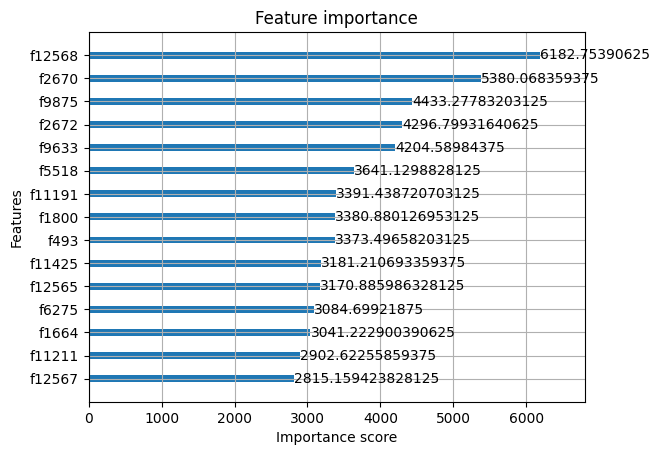

In [74]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

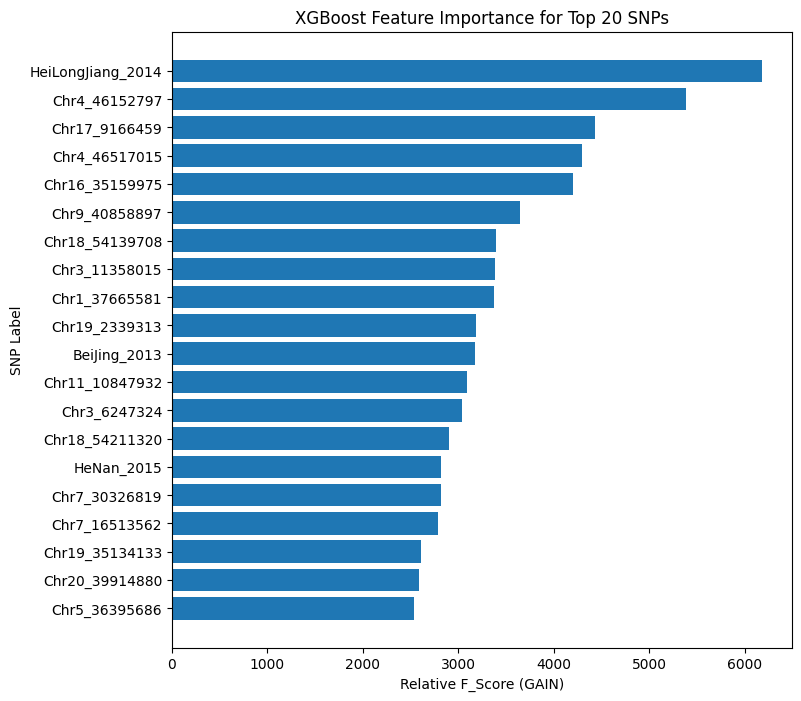

In [75]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [76]:
explainer = shap.Explainer(best_xgbr_model)

In [77]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

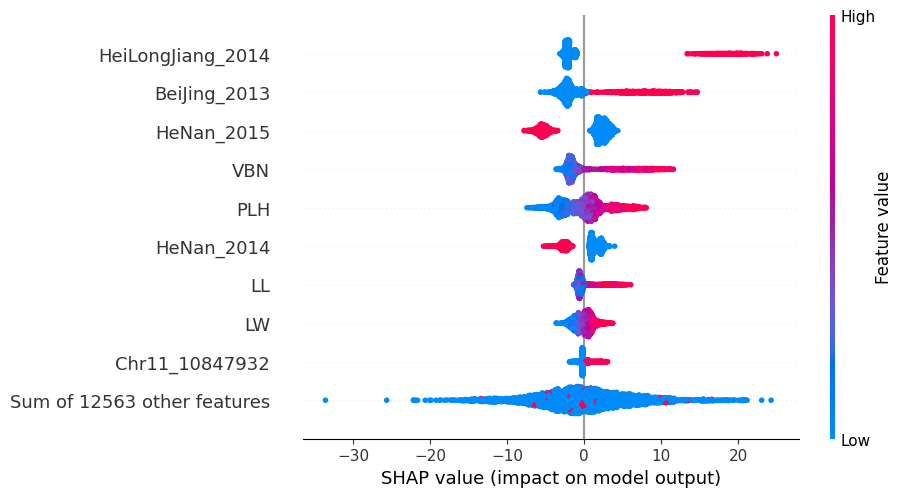

In [78]:
shap.plots.beeswarm(shap_values, show=False)

In [22]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [23]:
holdout_data = holdout_data.set_index('Line')

In [24]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [25]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [26]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [27]:
y_holdout = holdout_data.iloc[:, 251240:]

In [28]:
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [29]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [30]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 12572 entries, Chr1_123323 to landrace
dtypes: float64(4), int64(12568)
memory usage: 58.8+ MB


In [31]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.60
RMSE of Holdout: 9.62
Mean of Holdout: 117.42
This is 8.20% of the mean pheno data
0 117.0 112.21985
1 148.0 144.58113
2 117.0 114.07277
3 121.0 129.27513
4 119.0 124.47744
5 94.0 104.8552


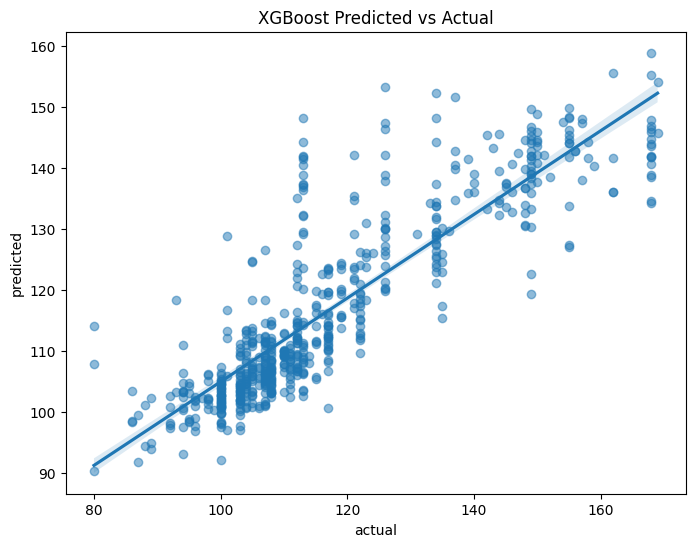

In [69]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [41]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 45 44.669983
1 39 53.036972
2 62 64.540695
3 47 51.514637
4 42 44.853477
5 40 40.37152


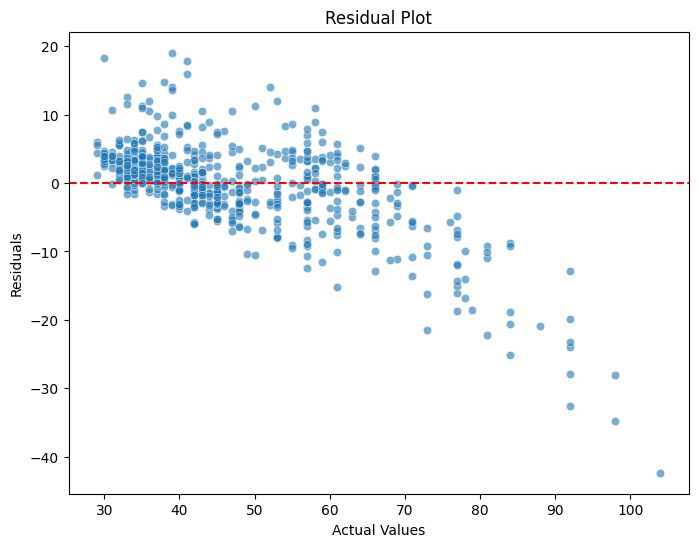

In [42]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [43]:
#### RF models

In [70]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 10), ('max_features', 'sqrt'), ('max_samples', 0.831450903982095), ('min_samples_leaf', 7), ('min_samples_split', 20), ('n_estimators', 59)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 23), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 10), ('min_samples_split', 11), ('n_estimators', 115)])

In [71]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.5208504446555
RMSE for dataset is:15.345277510041155& mean of this fold is 114.73877551020408
this is 13.374099071395834% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.510078565110005
RMSE for dataset is:16.472986014105114& mean of this fold is 115.9673469387755
this is 14.204848562071495% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -13.198648224540824
RMSE for dataset is:18.358114817064486& mean of this fold is 116.11836734693877
this is 15.80982857105979% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -13.183604991668847
RMSE for dataset is:17.23835391059727& mean of this fold is 115.47755102040816
this is 14.927883175796447% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -19.762520571035072
RMSE f

In [72]:
pickle.dump(best_rfr_model, open("gwas_top5_allfeats_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -13.56
RMSE of Holdout: 17.67
Mean of Holdout: 117.42
This is 15.05% of the mean pheno data
0 117.0 120.75589484577527
1 148.0 116.86878644213392
2 117.0 113.82781629410421
3 121.0 125.49289107290168
4 119.0 123.09908765286053
5 94.0 110.99749848989327


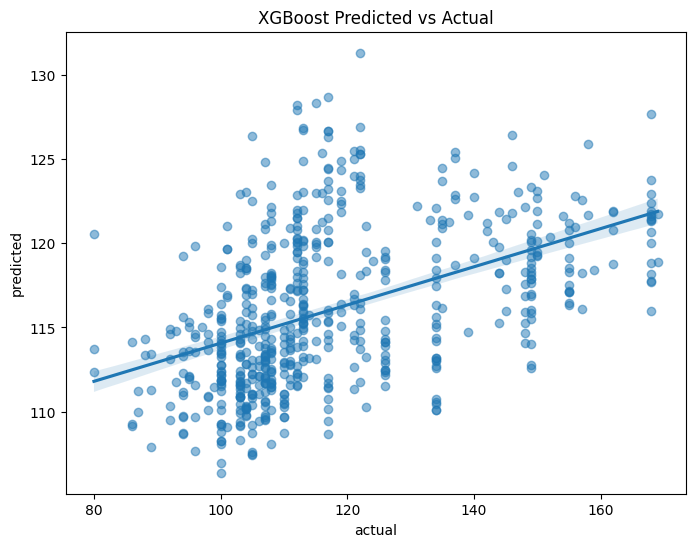

In [73]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [32]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [33]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7750625319684744
RMSE for dataset is:9.511810484838383& mean of this fold is 117.17551020408163
this is 8.11757547995473% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7485790391542706
RMSE for dataset is:9.910022150292388& mean of this fold is 118.2204081632653
this is 8.382666160825975% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7008844763893504
RMSE for dataset is:9.674302761752116& mean of this fold is 115.76326530612245
this is 8.356971217224697% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7253226248622054
RMSE for dataset is:9.08056557982893& mean of this fold is 116.2265306122449
this is 7.8128165161563015% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7696492058973391
RMSE for dataset 

In [34]:
pickle.dump(best_svr_model, open("gwas_top5_allfeats_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: 0.70
RMSE of Holdout: 9.64
Mean of Holdout: 117.42
This is 8.21% of the mean pheno data
0 117.0 119.55709866205132
1 148.0 143.43501217618166
2 117.0 115.02928810371111
3 121.0 124.26282769090687
4 119.0 124.1514224965257
5 94.0 93.29970045180778


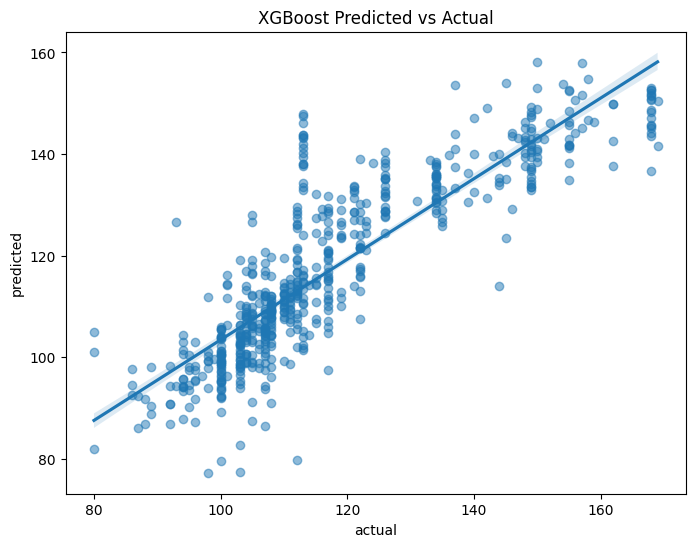

In [35]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [36]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12573 entries, Chr1_123323 to MD
dtypes: float64(5), int64(12568)
memory usage: 235.0+ MB


In [37]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s101,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,1,1,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [38]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s100,1,1,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,1,0
s101,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,1,1,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [39]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


# Run models

In [40]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [41]:
X_train.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_50433300,Chr20_50674780,Chr20_50927742,Chr20_51166518,Chr20_51479710,Chr20_51666590,Chr20_51666785,Chr20_52212855,Chr20_52247340,Chr20_52266575
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,1,0,0,0,0,0,0,0,0,...,1,2,2,2,1,0,0,2,0,0
s2862,1,0,2,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
s308,1,0,2,0,0,1,0,0,0,0,...,1,1,0,0,2,0,0,2,0,1
s202,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
s614,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [42]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [124]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])
Selection deleted


OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [125]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -48.99153384647597
RMSE for dataset is:19.772659384748202& mean of this fold is 117.58367346938776
this is 16.81582042926725% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -39.75382145843607
RMSE for dataset is:18.27455266079677& mean of this fold is 114.71836734693878
this is 15.92992742437632% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -38.40609669400535
RMSE for dataset is:17.95229034844678& mean of this fold is 114.94285714285714
this is 15.618447979011618% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -40.926547693842856
RMSE for dataset is:18.011752742336498& mean of this fold is 115.10612244897959
this is 15.647953696225105% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -33.89058390613648
RMSE for 

In [126]:
pickle.dump(best_xgbr_model, open("gwas_top5_onlysnps_xgbr_md.pickle.dat", "wb"))

<Figure size 2000x2000 with 0 Axes>

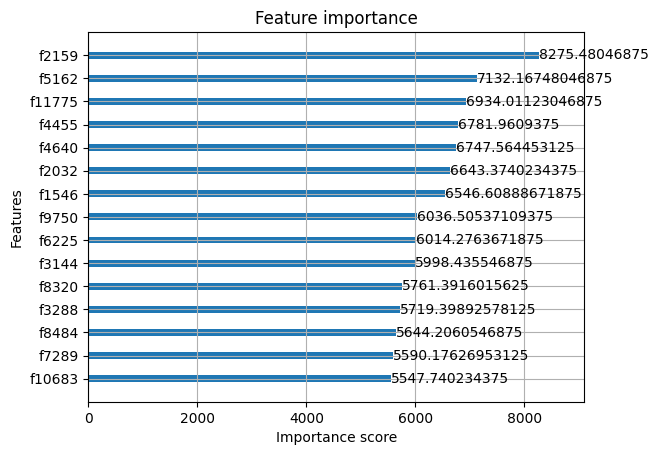

In [127]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

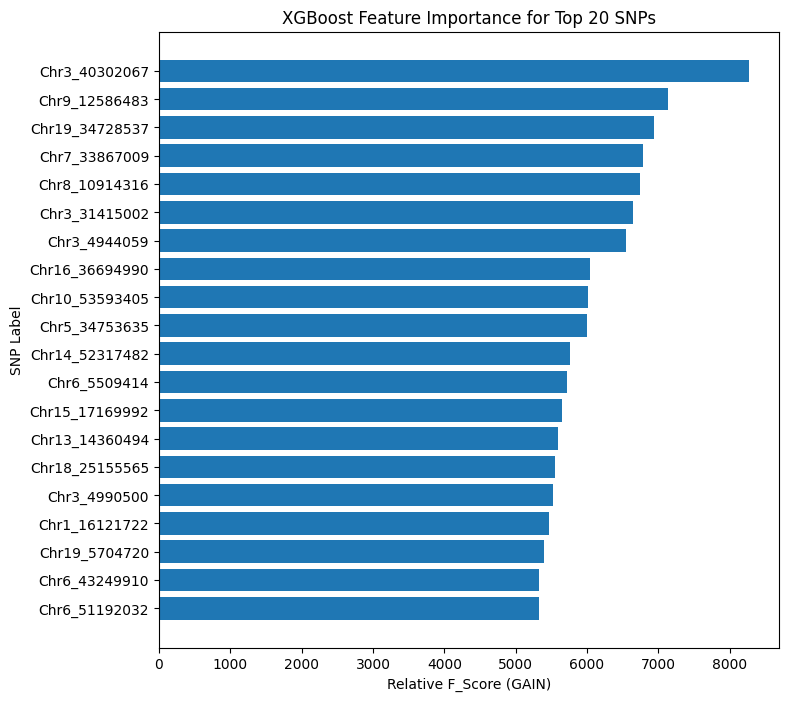

In [128]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [129]:
explainer = shap.Explainer(best_xgbr_model)

In [130]:
shap_values = explainer(gwas_snps_dupe)

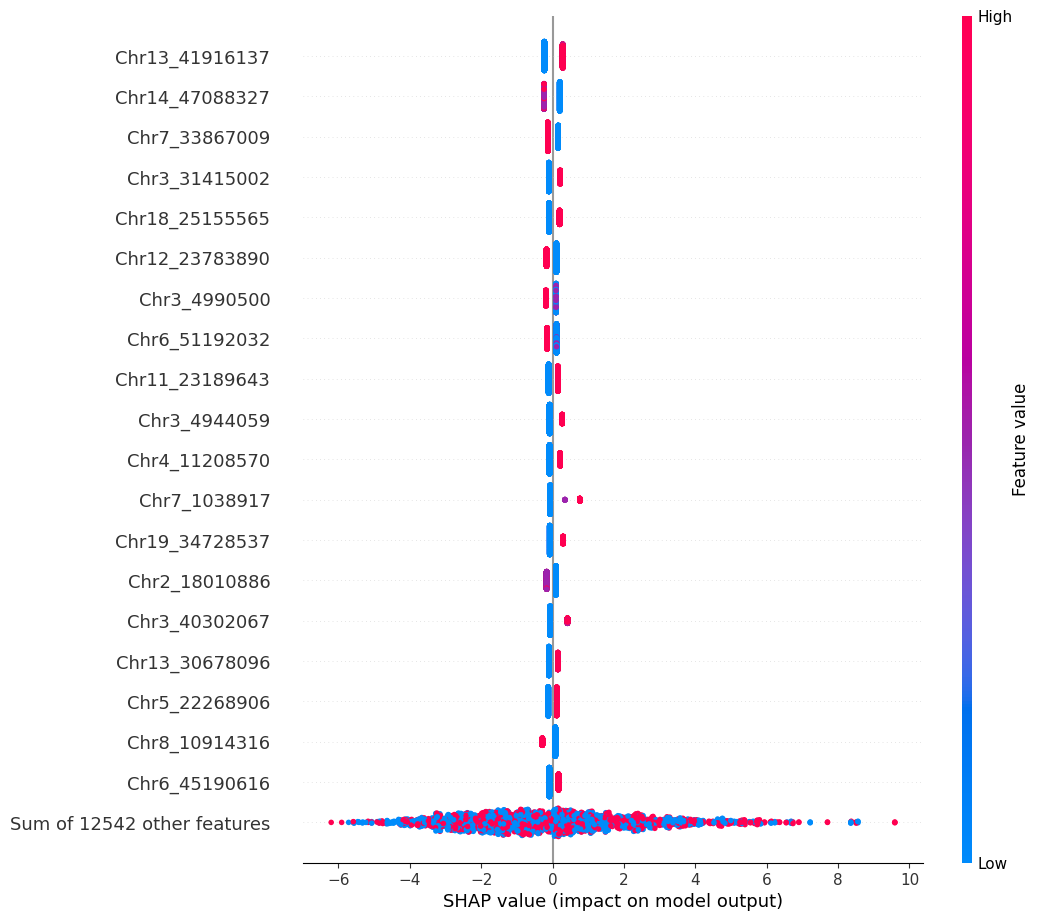

In [131]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [43]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [44]:
holdout_data = holdout_data.set_index('Line')

In [45]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [46]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [47]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [48]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 12561 entries, Chr1_123323 to Chr20_52266575
dtypes: int64(12561)
memory usage: 58.8+ MB


In [49]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -41.02
RMSE of Holdout: 18.93
Mean of Holdout: 117.42
This is 16.12% of the mean pheno data
0 117.0 120.800224
1 148.0 116.41199
2 117.0 111.0406
3 121.0 118.658295
4 119.0 118.658295
5 94.0 115.14838


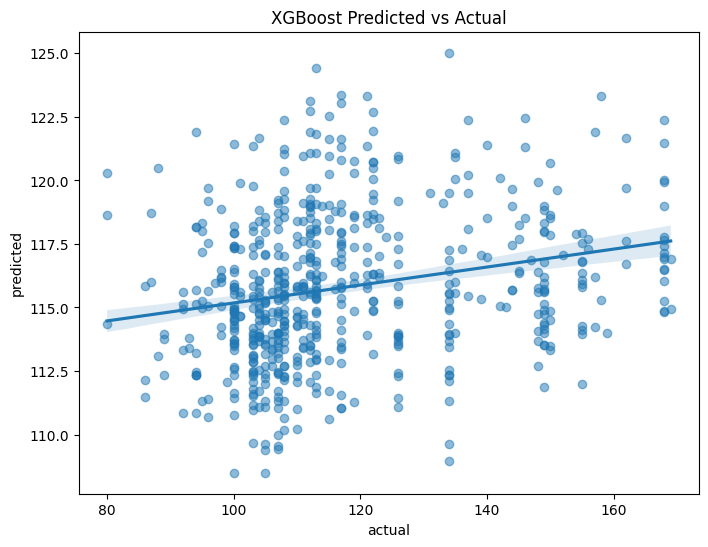

In [140]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [141]:
#### RF models

In [142]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 6), ('max_features', 'sqrt'), ('max_samples', 0.6694925484620775), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 500)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 6), ('max_features', 'sqrt'), ('max_samples', 0.6694925484620775), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 500)])

In [143]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -53.72687478327709
RMSE for dataset is:18.289699107286& mean of this fold is 117.15918367346939
this is 15.610982027888346% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -53.539994964604205
RMSE for dataset is:19.357561484182312& mean of this fold is 116.81224489795919
this is 16.571517396221623% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -59.90890188319942
RMSE for dataset is:19.332754027805347& mean of this fold is 116.15918367346939
this is 16.643328074817493% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -49.657246112516674
RMSE for dataset is:18.713710568155108& mean of this fold is 116.97142857142858
this is 15.998531262467727% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -46.04348116956667
RMSE fo

In [144]:
pickle.dump(best_rfr_model, open("gwas_top5_onlysnps_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -45.35
RMSE of Holdout: 19.07
Mean of Holdout: 117.42
This is 16.24% of the mean pheno data
0 117.0 120.25815787475061
1 148.0 116.07156115120209
2 117.0 113.10136037896264
3 121.0 120.1256161797438
4 119.0 120.1256161797438
5 94.0 113.20533684033407


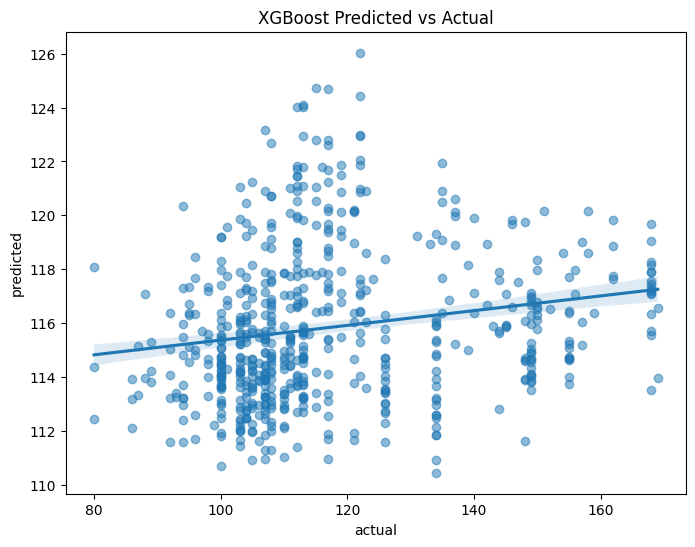

In [145]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [50]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1), ('kernel', 'sigmoid')])


In [51]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -58.34560099081958
RMSE for dataset is:19.92704109462309& mean of this fold is 116.24489795918367
this is 17.142293076484048% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -47.93528908848308
RMSE for dataset is:18.000018060443487& mean of this fold is 114.5265306122449
this is 15.71689805341835% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -54.53174092062163
RMSE for dataset is:19.236240832423505& mean of this fold is 115.3061224489796
this is 16.6827575360841% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -42.85506777768491
RMSE for dataset is:18.129778640736593& mean of this fold is 115.14693877551021
this is 15.74490718861602% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -50.27584400112434
RMSE for data

In [52]:
pickle.dump(best_svr_model, open("gwas_top5_onlysnps_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -65.76
RMSE of Holdout: 20.04
Mean of Holdout: 117.42
This is 17.07% of the mean pheno data
0 117.0 112.69579493233769
1 148.0 110.48594053786871
2 117.0 108.4743630018325
3 121.0 113.10584174272228
4 119.0 113.10584174272228
5 94.0 111.05199036687586


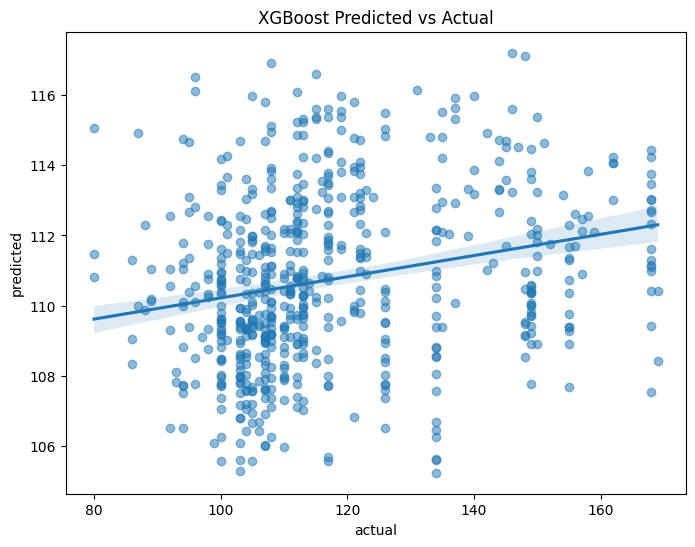

In [53]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [54]:
gwas_loc= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [55]:
gwas_loc_dupe= gwas_data.drop(['MD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [56]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s100 to s99
Columns: 12568 entries, Chr1_123323 to landrace
dtypes: int64(12568)
memory usage: 234.9+ MB


In [57]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,MD
Line,
s100,155.0
s100,115.0
s101,149.0
s1014,108.0
s1014,104.0


# Run models

In [58]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [59]:
X_train.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2674,1,1,0,0,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,1,0
s2862,1,0,2,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
s308,1,0,2,0,0,1,0,0,0,0,...,2,0,1,0,1,0,0,0,0,1
s202,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
s614,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [60]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [61]:
print(y_train[~np.isfinite(y_train)])

[]


In [88]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5674822680185702), ('colsample_bytree', 0.7270834329224792), ('gamma', 5.7736140327783475e-05), ('learning_rate', 0.059949767923085394), ('max_delta_step', 16), ('max_depth', 22), ('min_child_weight', 10), ('n_estimators', 196), ('reg_alpha', 0.0394786915183722), ('reg_lambda', 0.0004974412640184764), ('subsample', 0.7829413607977038)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5674822680185702), ('colsample_bytree', 0.7270834329224792), ('gamma', 5.7736140327783475e-05), ('learning_rate', 0.059949767923085394), ('max_delta_step', 16), ('max_depth', 22), ('min_child_weight', 10), ('n_estimators', 196), ('reg_alpha', 0.0394786915183722), ('reg_lambda', 0.0004974412640184764), ('subsample', 0.7829413607977038)])
Selection deleted


OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [90]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5920328354193587
RMSE for dataset is:9.851298680058363& mean of this fold is 118.9265306122449
this is 8.283516410798294% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7034666505065061
RMSE for dataset is:7.980072991245696& mean of this fold is 114.00408163265305
this is 6.999813407522809% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6417572300373049
RMSE for dataset is:9.306154378108216& mean of this fold is 115.75510204081633
this is 8.039519825939749% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6463277676132204
RMSE for dataset is:9.303864672435674& mean of this fold is 118.09387755102041
this is 7.878363269438841% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6895788656208353
RMSE for datase

In [91]:
pickle.dump(best_xgbr_model, open("gwas_top5_onlyloc_xgbr_md.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_onlyloc_xgbr_md.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

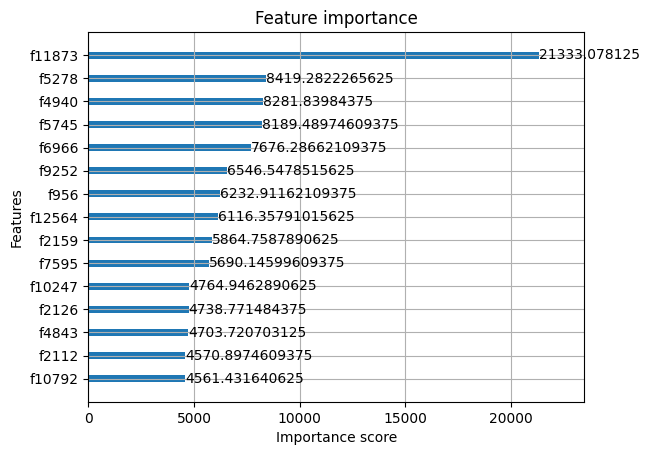

In [92]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

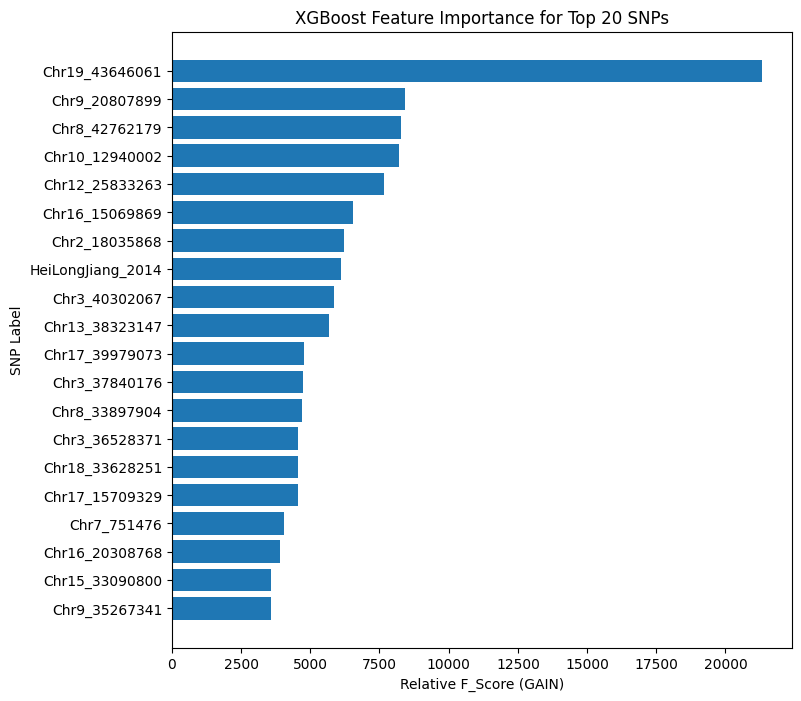

In [93]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

In [94]:
explainer = shap.Explainer(best_xgbr_model)

In [95]:
shap_values = explainer(gwas_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

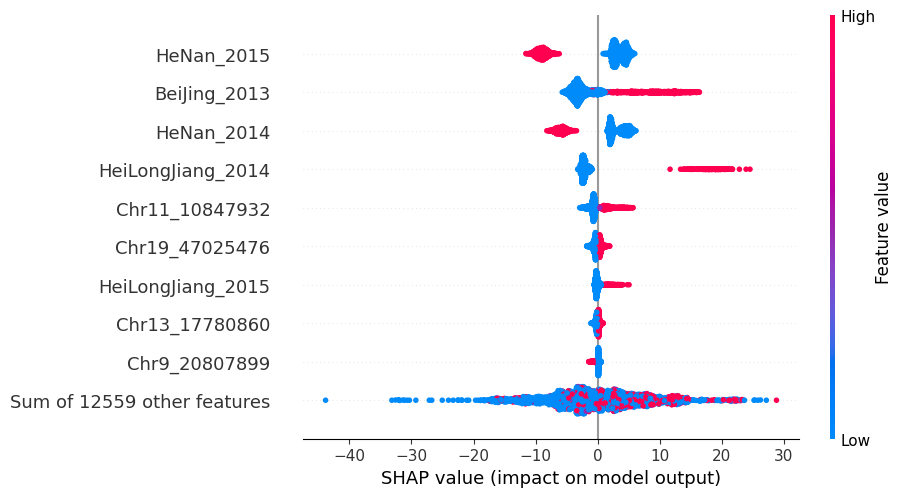

In [96]:
shap.plots.beeswarm(shap_values, show=False)

In [62]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_md.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019_HeNan_2014,s1019,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2015,s101,0,0,1,0,0,1,1,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [63]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s1014,0,0,0,0,0,0,0,0,0,0,...,111.7330,8.66667,1,0,0,0,0,0,1,148.0
s1019,0,0,0,0,0,0,0,0,0,0,...,63.4000,5.40000,0,1,0,0,0,0,1,117.0
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101,0,0,1,0,0,1,1,0,0,0,...,58.0000,2.60000,0,0,0,0,1,0,1,119.0


In [64]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.7330,8.66667,1,0,0,0,0,0,1
s1019,0,0,0,0,0,0,0,0,0,0,...,6.37333,63.4000,5.40000,0,1,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,9.97400,58.0000,2.60000,0,0,0,0,1,0,1


In [65]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,MD
Line,
s100,117.0
s1014,148.0
s1019,117.0
s101,121.0
s101,119.0


In [66]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [67]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 613 entries, s100 to s98
Columns: 12568 entries, Chr1_123323 to landrace
dtypes: int64(12568)
memory usage: 58.8+ MB


In [68]:
X_holdout.head()

,Chr1_123323,Chr1_123617,Chr1_155648,Chr1_213637,Chr1_213719,Chr1_213796,Chr1_214156,Chr1_236602,Chr1_236699,Chr1_324064,...,Chr20_52212855,Chr20_52247340,Chr20_52266575,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s1019,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,1,0,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,1,0,0,0,0,0,1
s101,0,0,0,0,0,0,0,1,1,1,...,0,1,0,0,0,0,0,1,0,1


In [69]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.57
RMSE of Holdout: 9.68
Mean of Holdout: 117.42
This is 8.24% of the mean pheno data
0 117.0 112.097046
1 148.0 145.8587
2 117.0 115.246
3 121.0 132.0167
4 119.0 126.050964
5 94.0 103.77376


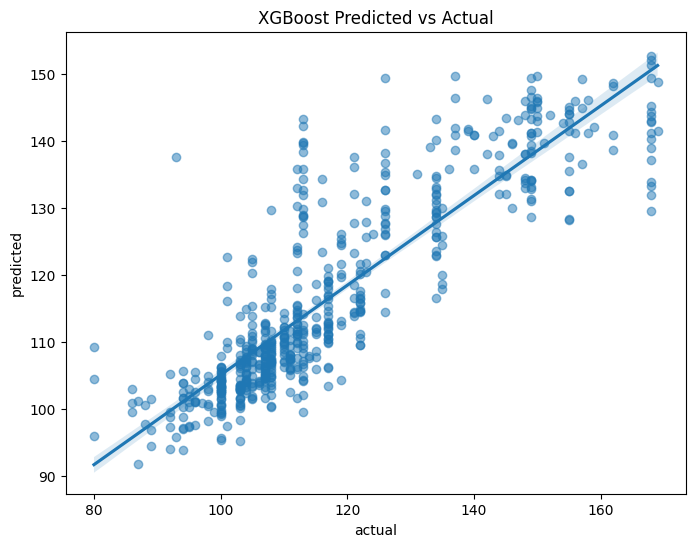

In [106]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [107]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 117.0 112.097046
1 148.0 145.8587
2 117.0 115.246
3 121.0 132.0167
4 119.0 126.050964
5 94.0 103.77376


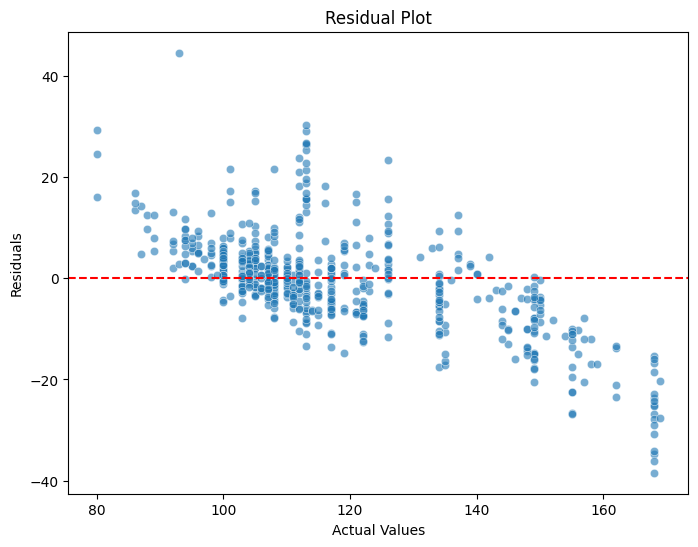

In [108]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [109]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 17), ('max_features', 'sqrt'), ('max_samples', 0.566541041264009), ('min_samples_leaf', 2), ('min_samples_split', 20), ('n_estimators', 358)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 17), ('max_features', 'sqrt'), ('max_samples', 0.566541041264009), ('min_samples_leaf', 2), ('min_samples_split', 20), ('n_estimators', 358)])

In [112]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.44948303680902
RMSE for dataset is:16.8004299943167& mean of this fold is 115.38367346938776
this is 14.56049152289643% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.200692715371446
RMSE for dataset is:17.17005754708209& mean of this fold is 112.85714285714286
this is 15.213975041718308% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.603236853486033
RMSE for dataset is:18.601985737188734& mean of this fold is 117.01224489795918
this is 15.897469323326497% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -15.578723228328428
RMSE for dataset is:18.240426387272095& mean of this fold is 116.38367346938776
this is 15.672667689140992% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.6937570116812
RMSE for

In [113]:
pickle.dump(best_rfr_model, open("gwas_top5_onlyloc_rfr_md.pickle.dat", "wb"))

R^2 Value of Holdout: -12.32
RMSE of Holdout: 18.20
Mean of Holdout: 117.42
This is 15.50% of the mean pheno data
0 117.0 124.15537604440392
1 148.0 115.06109422951035
2 117.0 113.66624678568711
3 121.0 125.52976263686575
4 119.0 124.66960887432558
5 94.0 113.89064438212922


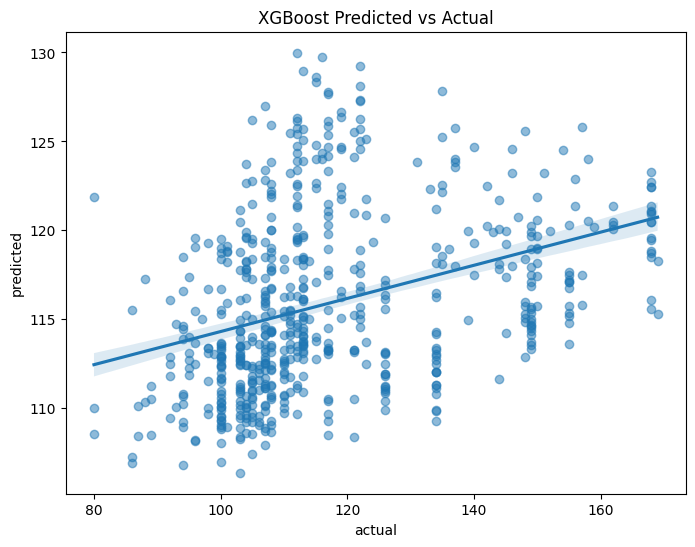

In [114]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [70]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [71]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.728302540139403
RMSE for dataset is:8.720045357203892& mean of this fold is 114.42857142857143
this is 7.620514044997159% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7416252630228488
RMSE for dataset is:8.971581034205688& mean of this fold is 117.99183673469388
this is 7.603560790716735% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6813781157694019
RMSE for dataset is:10.219234060871877& mean of this fold is 117.26122448979592
this is 8.714930366227886% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7745166486009222
RMSE for dataset is:8.543765191447516& mean of this fold is 117.27755102040817
this is 7.28508151569499% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7181500726430559
RMSE for datase

In [72]:
pickle.dump(best_svr_model, open("gwas_top5_onlyloc_svr_md.pickle.dat", "wb"))

R^2 Value of Holdout: 0.67
RMSE of Holdout: 9.96
Mean of Holdout: 117.42
This is 8.48% of the mean pheno data
0 117.0 121.49986483380425
1 148.0 140.14235808613884
2 117.0 114.50004541503048
3 121.0 126.3100763127687
4 119.0 128.3097983440458
5 94.0 96.38807966867634


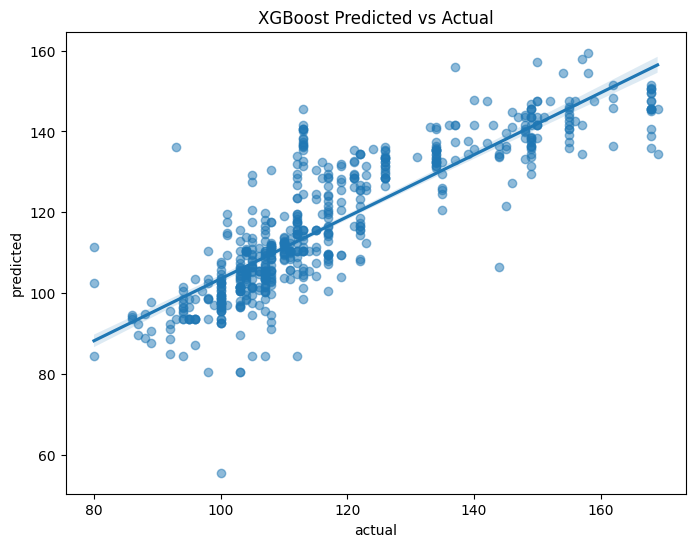

In [73]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

In [74]:
X_holdout.shape

(613, 12568)